<div style="background-color: darkred; padding: 10px; color: white;">

# Train Segmentation Model

</div>

### Imports

In [1]:
from torch.utils.data import DataLoader
from tqdm import tqdm

import numpy as np
import os

from aind_exaspim_neuron_segmentation.machine_learning.data_handling import TrainDataset, ValidateDataset
from aind_exaspim_neuron_segmentation.machine_learning.train import Trainer
from aind_exaspim_neuron_segmentation.utils import img_util, util

<div style="background-color: darkblue; padding: 10px; color: white;">

## Section 1: Load Data
    
</div>

### Initializations

In [2]:
# Parameters
affinity_mode = True
patch_shape = (96, 96, 96)
transform = True

# Paths
img_paths = [
    's3://aind-benchmark-data/3d-image-compression/blocks/block_000/input.zarr/0',
]
label_paths = [
    's3://aind-benchmark-data/3d-image-compression/blocks/block_000/Fill_Label_Mask.zarr/0',
]

### Check Train Dataset

In [3]:
# Create dataset
train_dataset = TrainDataset(
    img_paths,
    label_paths,
    affinity_mode=affinity_mode,
    patch_shape=patch_shape,
    transform=transform
)

Loading Images: 100%|██████████| 1/1 [00:06<00:00,  6.75s/it]


s3://aind-benchmark-data/3d-image-compression/blocks/block_000/input.zarr/0
s3://aind-benchmark-data/3d-image-compression/blocks/block_000/Fill_Label_Mask.zarr/0


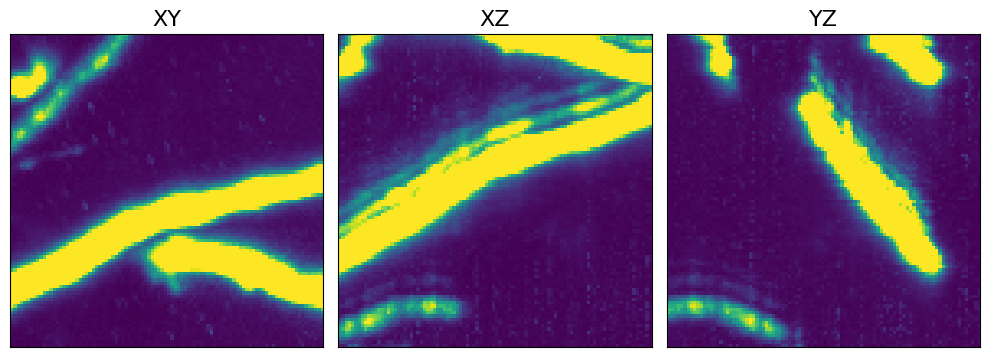

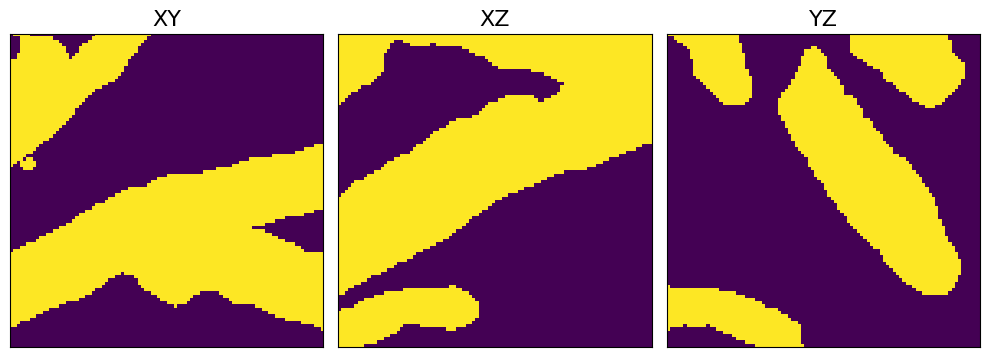

In [4]:
# Sample Example
i, input_i, label_mask_i = train_dataset.sample_patch()
print(train_dataset.input_img_paths[i])
print(train_dataset.label_mask_paths[i])

# Visualize example
img_util.plot_mips(input_i[0, ...])
img_util.plot_mips(label_mask_i[0, ...])

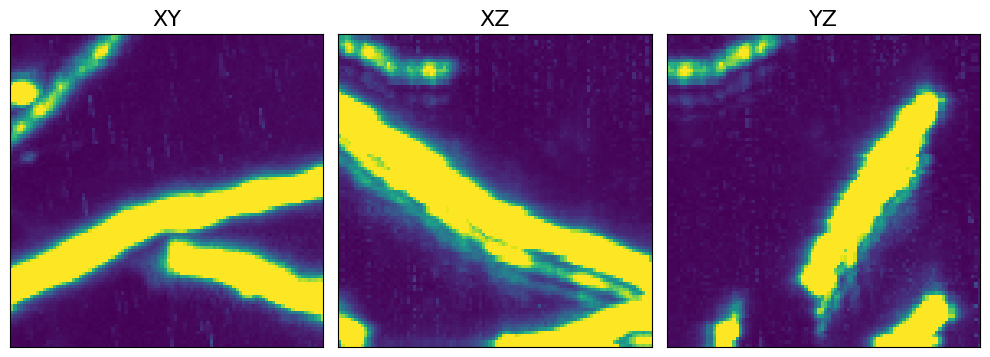

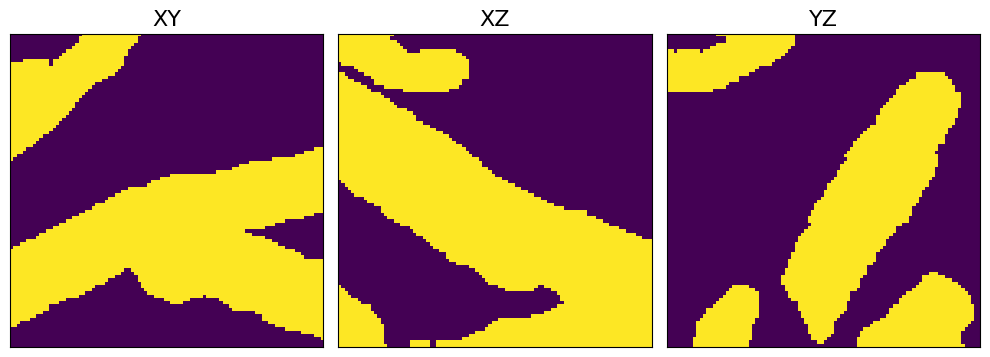

In [5]:
# Check image augmentation
t_input_i, t_label_mask_i = train_dataset.transform(*(input_i, label_mask_i))

img_util.plot_mips(t_input_i[0, ...])
img_util.plot_mips(t_label_mask_i[0, ...])

### Check Validate Dataset

Loading Images: 100%|██████████| 1/1 [00:04<00:00,  4.14s/it]


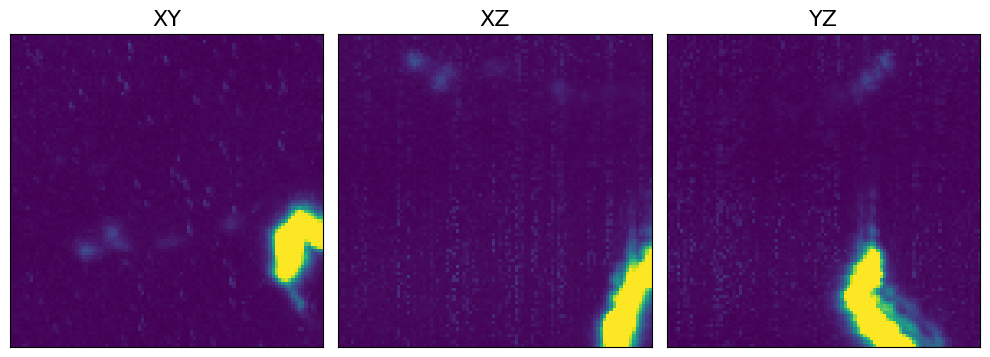

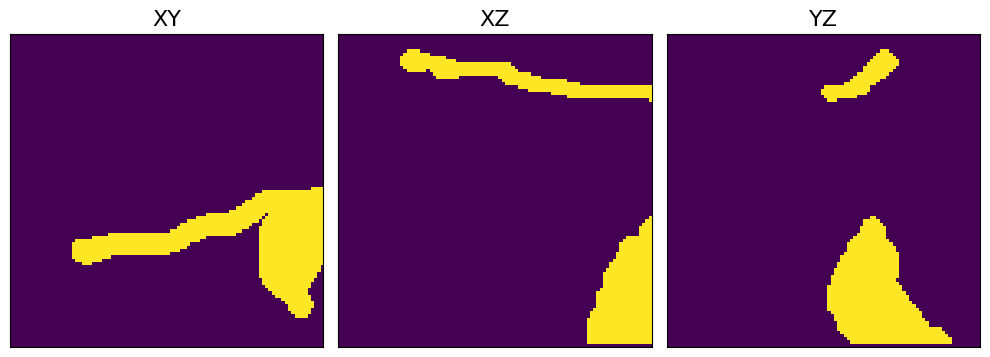

In [6]:
# Create dataset
val_dataset = ValidateDataset(
    img_paths,
    label_paths,
    affinity_mode=affinity_mode,
    patch_shape=patch_shape
)

# Visualize Example
input_i, label_mask_i = val_dataset[0]
img_util.plot_mips(input_i[0, ...])
img_util.plot_mips(label_mask_i[0, ...])

### Check Dataloaders

In [7]:
# Check train dataloader
print("Checking Train Dataloader...")
train_dataloader = DataLoader(
    train_dataset,
    batch_size=8,
    pin_memory=True
)
for batch_inputs, batch_labels in train_dataloader:
    print("   input.shape:", batch_inputs.shape)
    print("   label_mask.shape:", batch_labels.shape)
    break

# Check validation dataloading
print("\nChecking Validation Dataloader...")
val_dataloader = DataLoader(
    val_dataset,
    batch_size=8,
    pin_memory=True
)
for batch_inputs, batch_labels in val_dataloader:
    print("   input.shape:", batch_inputs.shape)
    print("   label_mask.shape:", batch_labels.shape)
    break

Checking Train Dataloader...
   input.shape: torch.Size([4, 1, 96, 96, 96])
   label_mask.shape: torch.Size([4, 3, 96, 96, 96])

Checking Validation Dataloader...
   input.shape: torch.Size([8, 1, 96, 96, 96])
   label_mask.shape: torch.Size([8, 3, 96, 96, 96])


In [8]:
stop

NameError: name 'stop' is not defined

<div style="background-color: darkblue; padding: 10px; color: white;">

## Section 2: Train Model
    
</div>

In [ ]:
# Initializations
output_dir = "/root/capsule/results/"
trainer = Trainer(output_dir, batch_size=8)

In [ ]:
# Check steps
trainer.train_step(train_dataloader, 0)
trainer.validate_step(val_dataloader, 0)

In [ ]:
# Check main train routine
trainer.run(train_dataset, val_dataset)